# 402 Project 1

### Retail Trader Survival — Who Blows Up, Survives
[Open Kaggle Link](https://www.kaggle.com/datasets/sergionefedov/retail-trader-survival-who-blows-up-survives/data)

The dataset specifically focuses on retail traders themselves. Most data about stock trading will be about price data, but here the dataset looks at features based on what a trader does (behavior) and the scenarioes they would trade in (circumstances). Each feature is labeled as such, and target variables measure net return and if the account blew up. 

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve

#randomly sample 1000 rows from the dataset to reduce memory usage, random seed to ensure reproducibility
random_seed = 42
df = pd.read_csv("retail_trader_master.csv")
df=df.sample(n=1000, random_state=random_seed)

The dataset contains 21 features:
- trader_id (string)
- age
- prior_experience_years (years)
- starting_capital (USD) -circumstance
- account_age_months (months)
- instrument (stock/etf/forex/crypto/options/futures)
- market_regime (bull/choppy/bear) -circumstance
- broker_cost_bps -circumstance
- risk_per_trade_pct (%) -behavior
- avg_leverage -behavior
- trades_per_month -behavior
- uses_stop_loss (binary, 1 if consistently use stop losses) -behavior
- avg_win_hold_days -behavior
- avg_loss_hold_days -behavior
- diversification (0-10) -behavior
- journals_trades (0-2) -behavior
- revenge_trading (0-10) -behavior
- overconfidence (0-10) -behavior
- follows_plan (0-10) -behavior
- chases_volatility (0-10) -behavior
- position_sizing_discipline (0-10) -behavior

And 3 targets:

- net_return_pct (%)
- profitable (binary, 1 if net return >0)
- blew_up (binary, 1 if lost >=70% of account)



In [3]:
#display part of the data, check for nulls and duplicates
display(df.head())
display(df.isnull().sum())
display(df.duplicated().sum())

,trader_id,age,prior_experience_years,starting_capital,account_age_months,instrument,market_regime,broker_cost_bps,risk_per_trade_pct,avg_leverage,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
33553,TRD033553,50,0.3,12340.0,14,stocks,choppy,23.7,2.22,1.0,...,5.7,2,9.1,5.4,4.1,7.8,7.0,-40.0,0,1
9427,TRD009427,35,4.5,6980.0,13,stocks,bear,12.4,2.83,1.8,...,3.9,1,4.7,4.2,3.8,9.5,8.5,-3.8,0,0
199,TRD000199,39,1.0,4440.0,12,forex,bull,6.0,0.36,6.1,...,3.3,1,6.0,5.7,5.2,8.0,8.9,-40.0,0,1
12447,TRD012447,52,2.9,6400.0,24,futures,choppy,15.8,2.01,10.8,...,3.0,0,8.3,3.4,0.0,7.8,5.8,1.8,1,0
39489,TRD039489,40,2.9,26250.0,5,crypto,bull,14.4,0.81,3.0,...,2.3,2,8.9,4.3,5.3,7.0,8.0,17.1,1,0


trader_id                     0
age                           0
prior_experience_years        0
starting_capital              0
account_age_months            0
instrument                    0
market_regime                 0
broker_cost_bps               0
risk_per_trade_pct            0
avg_leverage                  0
trades_per_month              0
uses_stop_loss                0
avg_win_hold_days             0
avg_loss_hold_days            0
diversification               0
journals_trades               0
revenge_trading               0
overconfidence                0
follows_plan                  0
chases_volatility             0
position_sizing_discipline    0
net_return_pct                0
profitable                    0
blew_up                       0
dtype: int64

np.int64(0)

The data does not have any null values or duplicates, so we do not need to clean up the values. 

In [4]:
display(df.describe())
display(df.info())

,age,prior_experience_years,starting_capital,account_age_months,broker_cost_bps,risk_per_trade_pct,avg_leverage,trades_per_month,uses_stop_loss,avg_win_hold_days,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.717000,2.243400,9292.600000,16.32300,11.76640,2.26821,6.191400,32.287000,0.492000,6.616200,...,4.073700,0.603000,5.063700,4.929000,5.365600,6.768900,7.413800,-21.354900,0.181000,0.448000
std,9.894484,1.920355,11651.220192,13.08885,8.09404,1.64651,5.791691,23.686699,0.500186,5.312489,...,2.023772,0.745618,2.264416,2.235504,2.262042,2.146894,2.117525,19.586417,0.385211,0.497537
min,18.000000,0.000000,200.000000,1.00000,0.50000,0.10000,1.000000,1.000000,0.000000,0.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,-55.800000,0.000000,0.000000
25%,27.000000,0.900000,2700.000000,7.00000,5.70000,1.11750,1.600000,14.750000,0.000000,2.775000,...,2.675000,0.000000,3.575000,3.400000,3.900000,5.200000,5.900000,-40.000000,0.000000,0.000000
50%,35.000000,1.700000,5475.000000,13.00000,10.10000,1.88000,4.200000,27.000000,0.000000,5.450000,...,4.100000,0.000000,4.900000,5.000000,5.400000,6.800000,7.600000,-24.200000,0.000000,0.000000
75%,41.250000,3.025000,11092.500000,23.00000,15.70000,2.95500,9.500000,44.000000,1.000000,9.025000,...,5.425000,1.000000,6.600000,6.500000,6.900000,8.400000,9.300000,-4.600000,0.000000,1.000000
max,70.000000,13.400000,130530.000000,95.00000,48.10000,12.05000,44.400000,145.000000,1.000000,45.100000,...,10.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,34.600000,1.000000,1.000000


<class 'pandas.DataFrame'>
Index: 1000 entries, 33553 to 13664
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trader_id                   1000 non-null   str    
 1   age                         1000 non-null   int64  
 2   prior_experience_years      1000 non-null   float64
 3   starting_capital            1000 non-null   float64
 4   account_age_months          1000 non-null   int64  
 5   instrument                  1000 non-null   str    
 6   market_regime               1000 non-null   str    
 7   broker_cost_bps             1000 non-null   float64
 8   risk_per_trade_pct          1000 non-null   float64
 9   avg_leverage                1000 non-null   float64
 10  trades_per_month            1000 non-null   int64  
 11  uses_stop_loss              1000 non-null   int64  
 12  avg_win_hold_days           1000 non-null   float64
 13  avg_loss_hold_days          1000 non-null   

None

### Exploratory Data Analysis

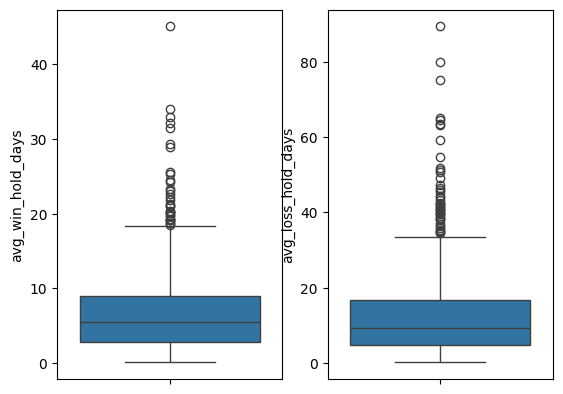

In [5]:
#boxplots of avg_win_hold_days and avg_loss_hold_days
plt.subplot(1, 2, 1)
win=sns.boxplot(data=df, y='avg_win_hold_days')
plt.subplot(1, 2, 2)
loss=sns.boxplot(data=df, y='avg_loss_hold_days')

Both boxplots have similar distribution for average days of holding trades whether win or loss. The median for average loss hold is lower than win, and has more outliers. 

<Axes: xlabel='trades_per_month', ylabel='Count'>

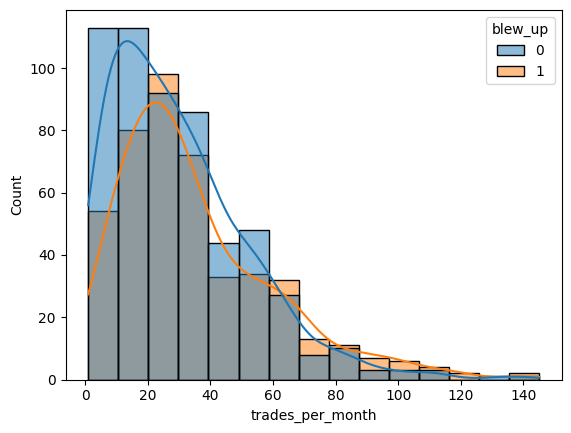

In [6]:
#histogram of trades_per_month differentiating between traders who blew up and those who didn't
sns.histplot(data=df, hue='blew_up', x='trades_per_month', bins=15, kde=True)

Traders who did not blow up mostly trade 0-20 times per month, whereas traders who did blow up (lost over 70 percent of their account) trade around 10-30 times per month. 

<Axes: xlabel='revenge_trading', ylabel='net_return_pct'>

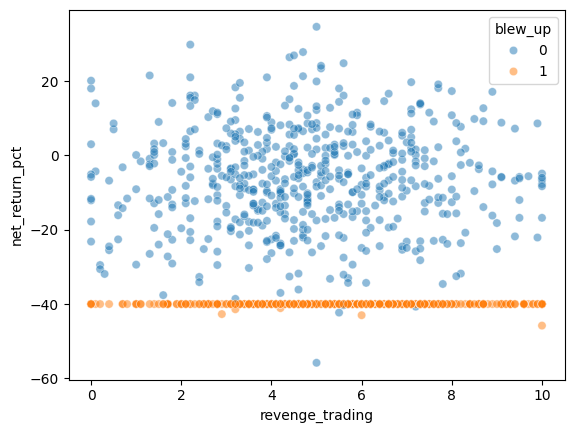

In [7]:
#scatterplot looking at revenge trading and net return percent (does revenge trading lead to lower returns?)
sns.scatterplot(data=df, x='revenge_trading', y='net_return_pct', alpha=0.5, hue='blew_up')

All accounts that have blown up are set to a default value for revenge trading. Accounts that do not blow up do not seem to have a correlation with frequency of revenge trading, but most traders are in the middle with how much they revenge trade. 

<Axes: xlabel='revenge_trading', ylabel='Density'>

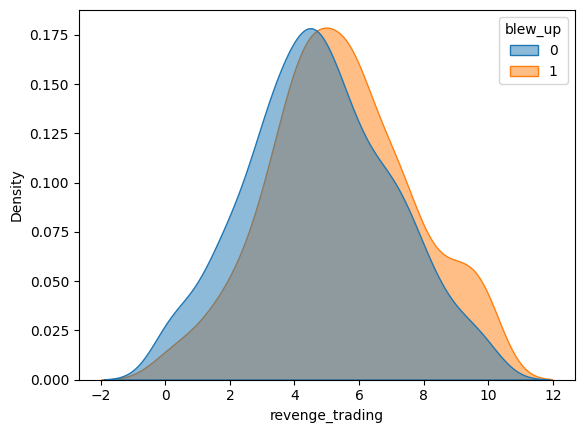

In [8]:
sns.kdeplot(data=df, x='revenge_trading', hue='blew_up', fill=True, common_norm=False, alpha=0.5)

Since the scatterplot did not give us much information, we looked at a density plot to see if traders actually revenge trade. The plot shows that most, whether or not their account blew up, return a 4-6 on revenge trading, meaning it is not a consistent habit amongst the dataset. 

<Axes: xlabel='broker_cost_bps', ylabel='risk_per_trade_pct'>

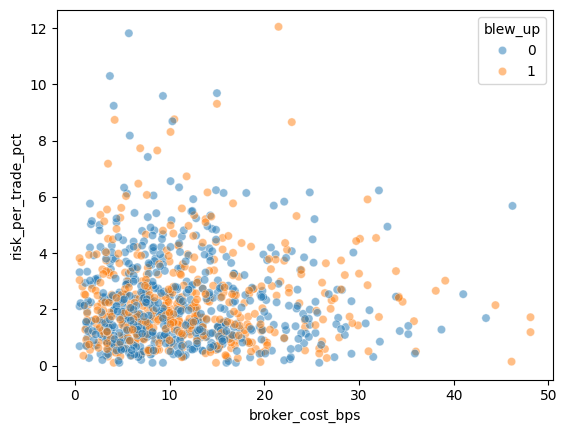

In [9]:
#scatterplot looking at broker cost bps and risk per trade pct (does higher broker cost lead to higher risk per trade?)
sns.scatterplot(data=df, x='broker_cost_bps', y='risk_per_trade_pct', alpha=0.5, hue='blew_up')

Most data points are clustered between 0-20 basis points and 0-5 for risk. There does not seem to be a correlation between broker cost and the risk per trade.

**Goal:** Predict whether a trader "survives" or "blows up" their account (binary classification) based on features like leverage used, position sizing, win rate, drawdown history, and trading style.

**Why it matters:** Retail trading has a famously high failure rate. A model that flags which behavioral/account patterns predict blowups could inform risk-management rules or serve as an early-warning system.

**Target:** `blew_up` (1 if the trader lost 70% or more of their account). Note that `net_return_pct` and `profitable` are also outcomes computed over the same trading period, so we won't use them as features — that would be leaking the answer into the model.

### Train/Test Split

In [11]:
X = df.drop(columns=['blew_up', 'net_return_pct', 'profitable', 'trader_id'])
y = df['blew_up']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_seed, stratify=y)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print('Blowup rate - train:', round(y_train.mean(), 3), '| test:', round(y_test.mean(), 3))

Train size: 800
Test size: 200
Blowup rate - train: 0.448 | test: 0.45


We use a single 80/20 train/test split, stratified on `blew_up`. Hyperparameter tuning for both models below uses 5-fold cross-validation on the training set only, so the test set stays untouched until final evaluation.

### Feature Encoding and Rescaling

In [12]:
X_train = pd.get_dummies(X_train, columns=['instrument', 'market_regime'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['instrument', 'market_regime'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
numeric_cols = ['age', 'prior_experience_years', 'starting_capital', 'account_age_months',
                'broker_cost_bps', 'risk_per_trade_pct', 'avg_leverage', 'trades_per_month',
                'avg_win_hold_days', 'avg_loss_hold_days', 'diversification', 'revenge_trading',
                'overconfidence', 'follows_plan', 'chases_volatility', 'position_sizing_discipline']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train.head()

,age,prior_experience_years,starting_capital,account_age_months,broker_cost_bps,risk_per_trade_pct,avg_leverage,trades_per_month,uses_stop_loss,avg_win_hold_days,...,follows_plan,chases_volatility,position_sizing_discipline,instrument_etf,instrument_forex,instrument_futures,instrument_options,instrument_stocks,market_regime_bull,market_regime_choppy
27377,-0.791247,-0.690599,-0.454582,-0.791364,-0.079998,0.572982,-0.191596,0.859911,1,0.680875,...,-0.454484,1.137305,-0.053964,False,False,False,False,False,True,False
13519,-0.070293,-0.333700,-0.240306,0.439433,-1.320033,-0.606179,-0.367696,0.010983,1,-0.830746,...,-0.232514,-0.212888,-0.525784,False,True,False,False,False,False,True
47380,0.135694,-1.047498,-0.245251,-1.099063,-0.824019,1.278108,-0.191596,-0.583267,1,-0.167108,...,1.854005,-1.050939,1.219949,True,False,False,False,False,False,False
32755,-0.997233,-0.435672,-0.708417,-1.175988,-0.836419,-0.985407,3.013413,-1.347302,1,-0.462058,...,-1.564334,0.345812,-1.516606,False,True,False,False,False,False,True
6682,0.341681,5.682594,0.424775,0.362508,-1.047225,1.023315,-0.543795,-0.328588,0,0.459662,...,-0.365696,0.206137,-0.148328,False,False,False,False,True,True,False


### Model 1: Logistic Regression (Regularized)

We tune `C`, the inverse of the regularization strength $\lambda$ (so a small `C` means strong regularization), using grid search with 5-fold cross-validation on the training set.

In [4]:
parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=random_seed), parameters, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['C']
print('Best C:', best_C)
print('Best CV ROC-AUC:', round(grid_search.best_score_, 4))
logreg = LogisticRegression(C=best_C, max_iter=1000, random_state=random_seed)
logreg.fit(X_train, y_train)

NameError: name 'GridSearchCV' is not defined

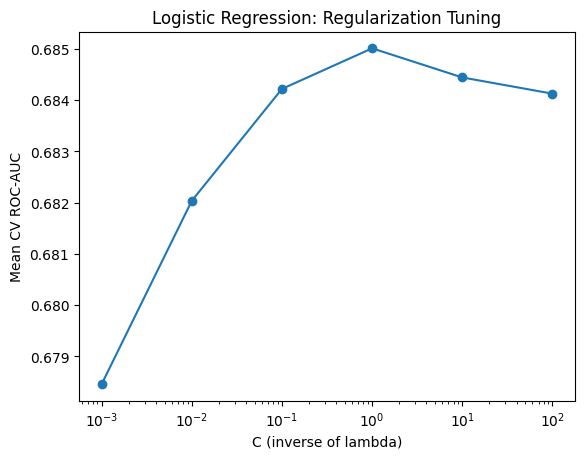

In [14]:
mean_scores = grid_search.cv_results_['mean_test_score']
plt.plot(parameters['C'], mean_scores, marker='o')
plt.xscale('log')
plt.xlabel('C (inverse of lambda)')
plt.ylabel('Mean CV ROC-AUC')
plt.title('Logistic Regression: Regularization Tuning')
plt.show()

Logistic Regression - Train Accuracy: 0.67
Logistic Regression - Test Accuracy: 0.695
Logistic Regression - Test Sensitivity (TPR): 0.633
Logistic Regression - Test Specificity (TNR): 0.745


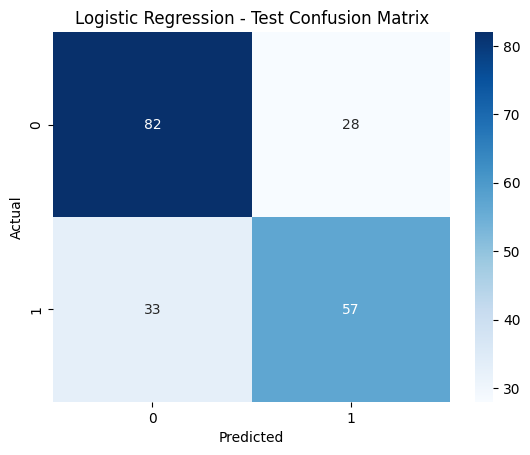

In [15]:
logreg_train_pred = logreg.predict(X_train)
logreg_test_pred = logreg.predict(X_test)
print('Logistic Regression - Train Accuracy:', round(accuracy_score(y_train, logreg_train_pred), 3))
print('Logistic Regression - Test Accuracy:', round(accuracy_score(y_test, logreg_test_pred), 3))
conf_M_logreg = pd.crosstab(y_test, logreg_test_pred)
TP = conf_M_logreg.iloc[1, 1]
FN = conf_M_logreg.iloc[1, 0]
FP = conf_M_logreg.iloc[0, 1]
TN = conf_M_logreg.iloc[0, 0]
print('Logistic Regression - Test Sensitivity (TPR):', round(TP / (TP + FN), 3))
print('Logistic Regression - Test Specificity (TNR):', round(TN / (TN + FP), 3))
sns.heatmap(conf_M_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model 2: Random Forest

We tune `n_estimators` (number of trees) and `max_depth` the same way, with grid search and 5-fold cross-validation.

In [5]:
parameters = {'n_estimators': [100, 200, 400], 'max_depth': [3, 5, 10, None]}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_seed),parameters, cv=5, scoring='roc_auc')
grid_search_rf.fit(X_train, y_train)
best_params = grid_search_rf.best_params_
print('Best params:', best_params)
print('Best CV ROC-AUC:', round(grid_search_rf.best_score_, 4))
rf = RandomForestClassifier(n_estimators=best_params['n_estimators'],max_depth=best_params['max_depth'],random_state=random_seed)
rf.fit(X_train, y_train)

NameError: name 'GridSearchCV' is not defined

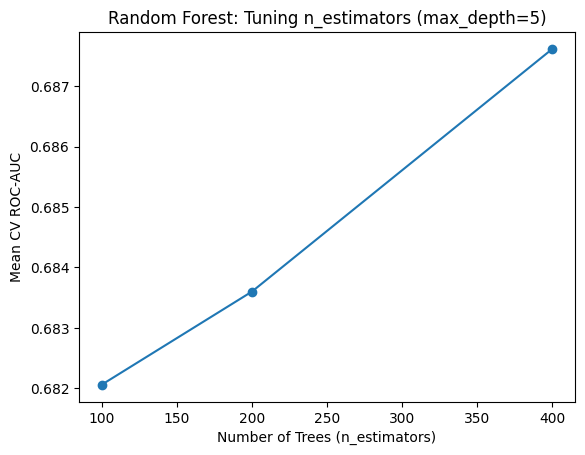

In [17]:
results = pd.DataFrame(grid_search_rf.cv_results_)
results_best_depth = results[results['param_max_depth'] == best_params['max_depth']]
plt.plot(results_best_depth['param_n_estimators'], results_best_depth['mean_test_score'], marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean CV ROC-AUC')
plt.title(f'Random Forest: Tuning n_estimators (max_depth={best_params["max_depth"]})')
plt.show()

Random Forest - Train Accuracy: 0.836
Random Forest - Test Accuracy: 0.655
Random Forest - Test Sensitivity (TPR): 0.456
Random Forest - Test Specificity (TNR): 0.818


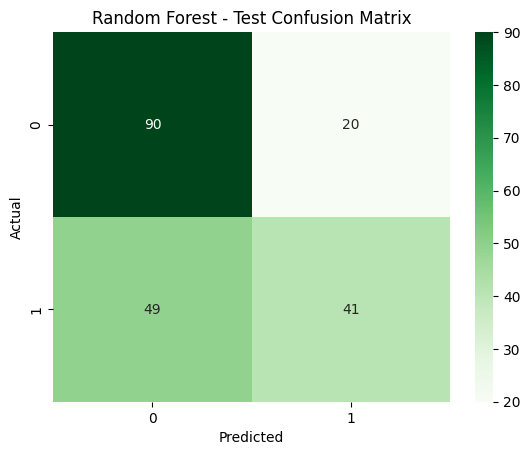

In [18]:
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)
print('Random Forest - Train Accuracy:', round(accuracy_score(y_train, rf_train_pred), 3))
print('Random Forest - Test Accuracy:', round(accuracy_score(y_test, rf_test_pred), 3))
conf_M_rf = pd.crosstab(y_test, rf_test_pred)
TP = conf_M_rf.iloc[1, 1]
FN = conf_M_rf.iloc[1, 0]
FP = conf_M_rf.iloc[0, 1]
TN = conf_M_rf.iloc[0, 0]
print('Random Forest - Test Sensitivity (TPR):', round(TP / (TP + FN), 3))
print('Random Forest - Test Specificity (TNR):', round(TN / (TN + FP), 3))
sns.heatmap(conf_M_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

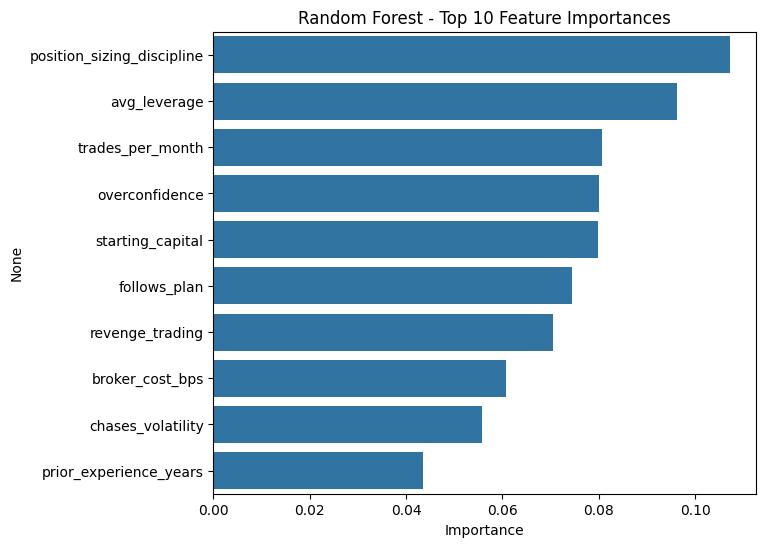

In [19]:
# which features mattered most to the random forest?
importance = pd.DataFrame(rf.feature_importances_, index=X_train.columns, columns=['Importance'])
importance = importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(7, 6))
sns.barplot(x='Importance', y=importance.index, data=importance)
plt.title('Random Forest - Top 10 Feature Importances')
plt.show()

### Model Comparison

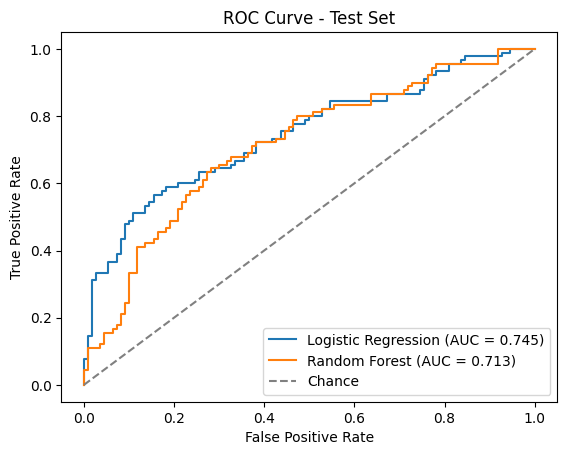

In [20]:
logreg_probs = logreg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, logreg_probs):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.show()

### Conclusion

Both models land in a similar, moderate range for distinguishing traders who blow up their account from those who don't (test ROC-AUC around 0.71-0.74), which makes sense given these are behavioral/account features rather than direct trade-by-trade outcomes.

- **Logistic Regression** generalized a bit better here: its train and test accuracy were close (0.67 vs 0.695), suggesting it wasn't overfitting, and it had a more balanced sensitivity/specificity trade-off (0.63 / 0.75).
- **Random Forest** had a noticeably larger train/test gap (0.836 train accuracy vs 0.655 test), a sign of some overfitting even after tuning `max_depth` and `n_estimators`. It also had lower sensitivity (0.46), meaning it missed more of the traders who actually blew up, though it was better at recognizing traders who did not blow up (specificity 0.82).
- Since this is meant to work as an early-warning tool, **catching actual blowups (sensitivity) matters more than overall accuracy** — a missed blowup is worse than a false alarm. On that basis, Logistic Regression is the stronger model on this run.
- The regularization-tuning curve showed performance was fairly flat across most `C` values, with the best fit at `C=1` — not heavily under- or over-regularized. The random forest curve showed the model benefiting from more trees up to a point before leveling off.
- The random forest's top features were `position_sizing_discipline`, `avg_leverage`, `trades_per_month`, `overconfidence`, and `starting_capital` — this lines up with the EDA earlier in the notebook, which flagged leverage and trading frequency as visibly different between traders who blew up and those who didn't.
- **Limitations:** we sampled down to 1,000 rows from the full 50,000-row dataset (mainly for speed while iterating); training on more data, or trying a higher-capacity model, would likely improve both models' scores.